In [9]:
# importing the libraries needed for data analysis

import pandas as pd        # used for data manipulation and analysis
import numpy as np         # used for numerical operations
import matplotlib.pyplot as plt   # used for plotting graphs
import seaborn as sns      # used for better visualizations

In [10]:
# loading the zomato dataset

df = pd.read_csv("zomato.csv", encoding="latin-1")

# displaying first 5 rows of the dataset to understand the structure

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [11]:
# checking number of rows and columns in dataset

df.shape

(9551, 21)

In [12]:
# displaying all column names in dataset

df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [13]:
# checking dataset structure and data types

df.info() #checking for missing data 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [14]:
# checking missing values in each column

df.isnull().sum() #below cusines have 9 missing values

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [15]:
# removing rows where cuisines are missing

df.dropna(subset=["Cuisines"], inplace=True) # here dropna removes missing values and subset = "cus" checks only cusine cloumn and inplace = true updates data set

# checking again to confirm missing values removed

df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [16]:
# checking dataset shape again after removing missing values

df.shape # Dataset is now clean

(9542, 21)

In [17]:
# loading country dataset

country = pd.read_excel("Country-Code.xlsx")

# checking first rows

country.head()

,Country Code,Country
0,1,India
1,14,Australia
2,30,Brazil
3,37,Canada
4,94,Indonesia


In [18]:
# merging country names with zomato dataset using Country Code

df = pd.merge(df, country, on="Country Code", how="left")

# checking result

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Phillipines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,Phillipines
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,No,4,4.9,Dark Green,Excellent,365,Phillipines
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Phillipines


In [19]:
# counting number of restaurants in each country

df["Country"].value_counts()

Country
India             8652
United States      425
United Kingdom      80
Brazil              60
UAE                 60
South Africa        60
New Zealand         40
Turkey              34
Australia           24
Phillipines         22
Indonesia           21
Singapore           20
Qatar               20
Sri Lanka           20
Canada               4
Name: count, dtype: int64

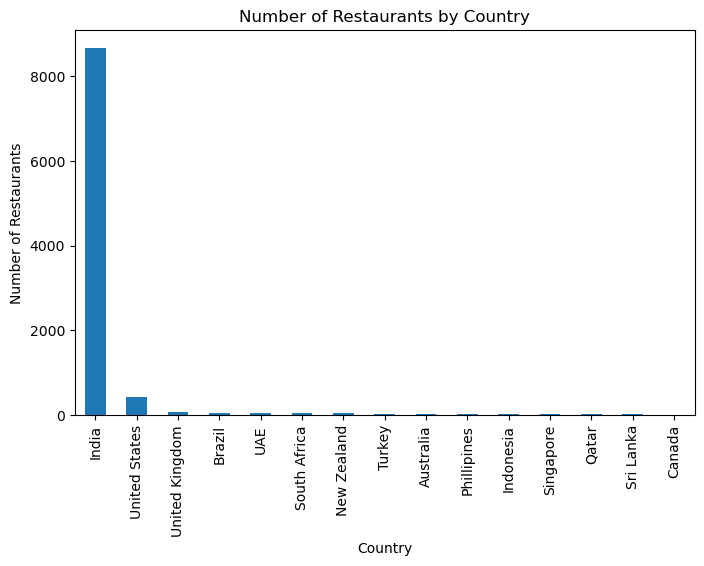

In [20]:
# plotting restaurant distribution by country

plt.figure(figsize=(8,5))

df["Country"].value_counts().plot(kind="bar")

plt.title("Number of Restaurants by Country")
plt.xlabel("Country")
plt.ylabel("Number of Restaurants")

plt.show()

-Most restaurants in the dataset are located in India.
-The United States has the second highest number of restaurants.
-Other countries such as UK, Brazil, UAE, and South Africa have significantly fewer restaurants.
-This indicates that the dataset is heavily concentrated in India.

In [21]:
# counting number of restaurants in each city

df["City"].value_counts().head(10)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Guwahati          21
Amritsar          21
Bhubaneshwar      21
Lucknow           21
Name: count, dtype: int64

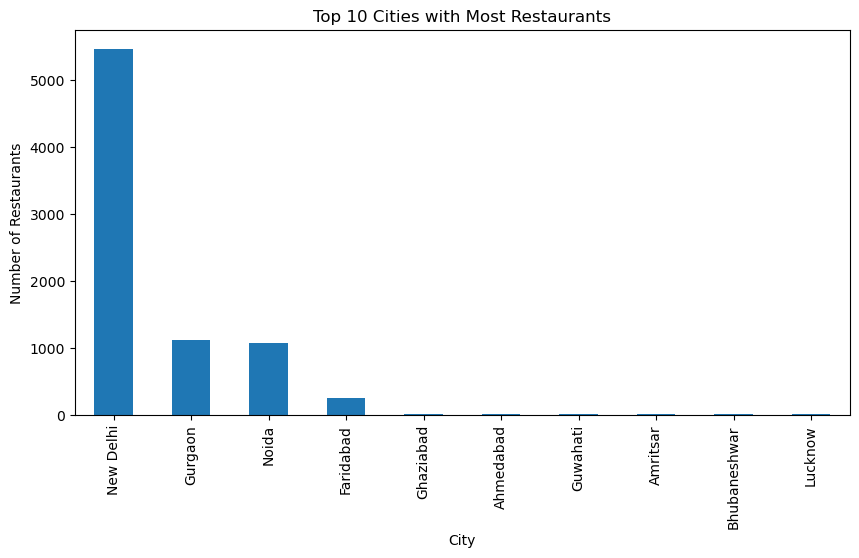

In [22]:
# plotting top 10 cities with most restaurants

plt.figure(figsize=(10,5))

df["City"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Cities with Most Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")

plt.show()

-New Delhi has the highest number of restaurants in the dataset.
-Gurgaon and Noida are the next cities with a large number of restaurants.
-Faridabad has significantly fewer restaurants compared to the top three.
-Other cities such as Ghaziabad, Ahmedabad, Guwahati, Amritsar, Bhubaneshwar and Lucknow have very small counts.
-This shows that the dataset is highly concentrated around the Delhi NCR region.

In [23]:
# splitting cuisines because one restaurant can have multiple cuisines

cuisines = df["Cuisines"].str.split(",")

# flattening the list of cuisines

all_cuisines = []

for c in cuisines:
    for i in c:
        all_cuisines.append(i.strip())

In [24]:
# The "Cuisines" column contains multiple cuisines in a single cell
# Example: "Italian, Pizza, Fast Food"
# So first we split them into separate cuisines

cuisines = df["Cuisines"].str.split(",")

# creating an empty list to store all cuisines separately
all_cuisines = []

# looping through each restaurant's cuisine list
for c in cuisines:
    
    # each restaurant can have multiple cuisines
    for i in c:
        
        # removing extra spaces and adding cuisine to list
        all_cuisines.append(i.strip())

In [25]:
# converting cuisine list into a pandas series so we can count frequency

cuisine_series = pd.Series(all_cuisines)

# counting how many times each cuisine appears
# head(10) shows top 10 cuisines

top_cuisines = cuisine_series.value_counts().head(10)

top_cuisines

North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64

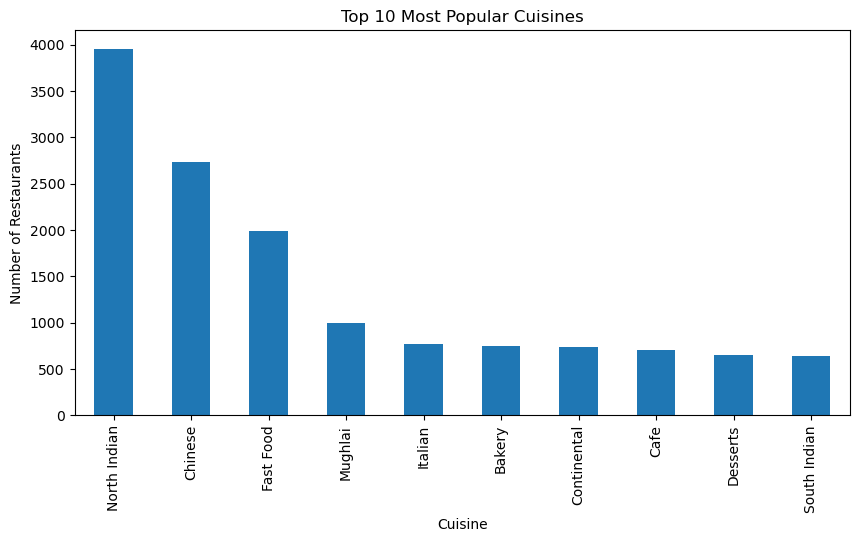

In [26]:
# plotting most popular cuisines

plt.figure(figsize=(10,5))

top_cuisines.plot(kind="bar")

plt.title("Top 10 Most Popular Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")

plt.show()

-North Indian cuisine is the most common cuisine in the dataset with the highest number of restaurants.
-Chinese and Fast Food are the next most popular cuisines.
-Other popular cuisines include Mughlai, Italian, Bakery, Continental, Cafe, Desserts and South Indian.
-This shows that Indian cuisine dominates the dataset, while international cuisines such as Italian and Continental are also popular.
-Cuisine popularity can help build recommendation systems by suggesting commonly preferred food types.

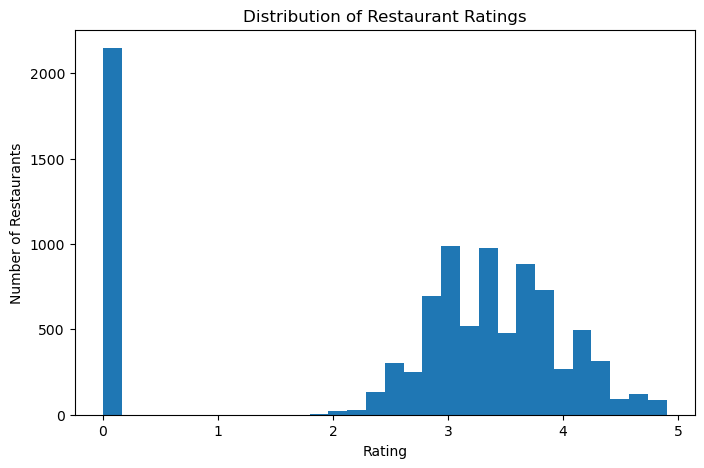

In [27]:
# plotting histogram-(shows how many values fall into each range like 1-2,2-3,3-4) of restaurant ratings

plt.figure(figsize=(8,5))

plt.hist(df["Aggregate rating"], bins=30)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")

plt.show()

-Many restaurants have ratings between 3.0 and 4.0.
-A large number of restaurants have rating 0 which usually indicates no ratings(the big bar is indicated there).
-Very few restaurants have ratings below 2.
-Some restaurants have very high ratings close to 4.5 or above.

In [28]:

# counting restaurants that provide online delivery

df["Has Online delivery"].value_counts()

Has Online delivery
No     7091
Yes    2451
Name: count, dtype: int64

-Most restaurants do not offer online delivery only few have online delivery

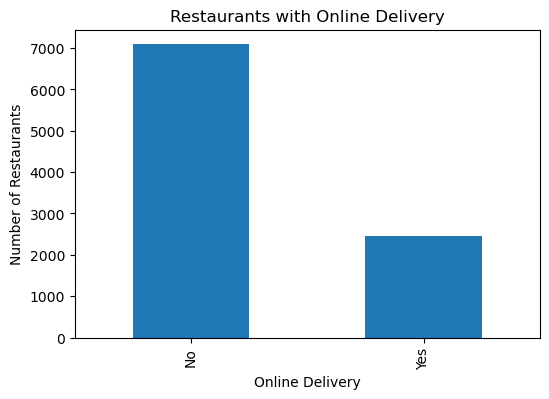

In [29]:
# plotting online delivery availability

plt.figure(figsize=(6,4))

df["Has Online delivery"].value_counts().plot(kind="bar")

plt.title("Restaurants with Online Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Number of Restaurants")

plt.show()

In [30]:
# checking average rating for restaurants with and without online delivery

df.groupby("Has Online delivery")["Aggregate rating"].mean()

Has Online delivery
No     2.463517
Yes    3.248837
Name: Aggregate rating, dtype: float64

-Restaurants with online delivery have higher ratings on average
-Restaurants without delivery tend to have lower ratings

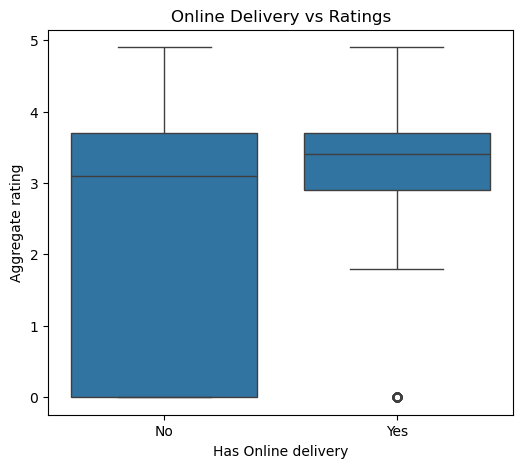

In [31]:
plt.figure(figsize=(6,5))

sns.boxplot(x="Has Online delivery", y="Aggregate rating", data=df)

plt.title("Online Delivery vs Ratings")

plt.show()

-Restaurants that offer online delivery tend to have higher average ratings compared to those that do not offer delivery.
-This may indicate that restaurants providing delivery services attract more customers and receive more feedback.
-Online delivery can therefore be an important factor in restaurant recommendation systems.

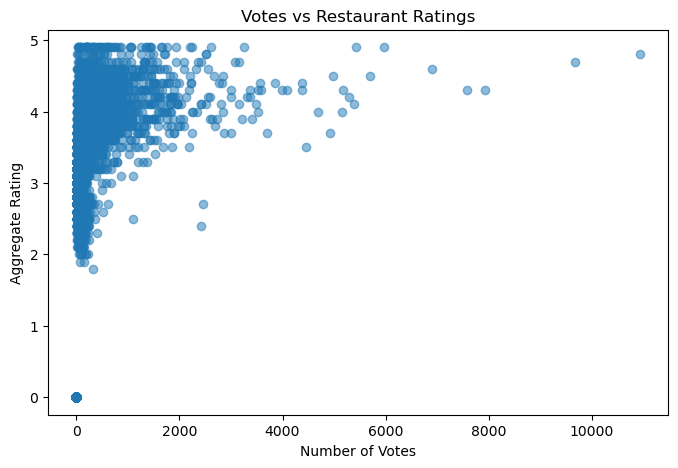

In [32]:
plt.figure(figsize=(8,5))

plt.scatter(df["Votes"], df["Aggregate rating"], alpha=0.5)

plt.title("Votes vs Restaurant Ratings")
plt.xlabel("Number of Votes")
plt.ylabel("Aggregate Rating")

plt.show()

-Most restaurants have fewer than 1000 votes.
-Restaurants with more votes generally have ratings above 3.
-Highly voted restaurants often have ratings between 4 and 4.5.
-Restaurants with very few votes have more variation in ratings.

-Restaurants with more votes tend to have higher and more reliable ratings.
-This indicates that popularity (votes) and quality (ratings) are related.
-Recommendation systems should consider both rating and number of votes to avoid recommending restaurants with very few reviews.

In [33]:
# counting restaurants in each price category

df["Price range"].value_counts()

Price range
1    4438
2    3113
3    1405
4     586
Name: count, dtype: int64

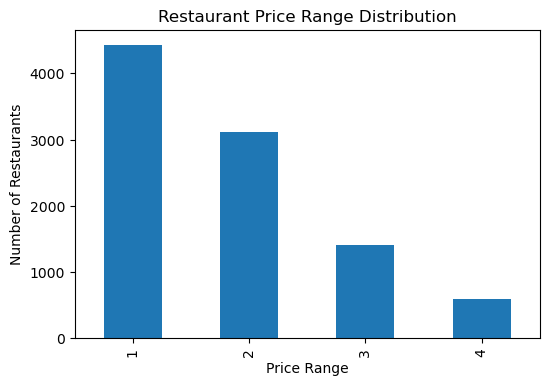

In [34]:
plt.figure(figsize=(6,4))

df["Price range"].value_counts().sort_index().plot(kind="bar")

plt.title("Restaurant Price Range Distribution")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")

plt.show()

-Most restaurants fall under price range 1, which represents low-cost restaurants.
-Price range 2 (moderate pricing) is the second most common category.
-Fewer restaurants belong to price range 3 and price range 4, which represent expensive and very expensive restaurants.
-This indicates that the majority of restaurants in the dataset are affordable or moderately priced.
-This information can help recommendation systems suggest restaurants based on user budget preferences.

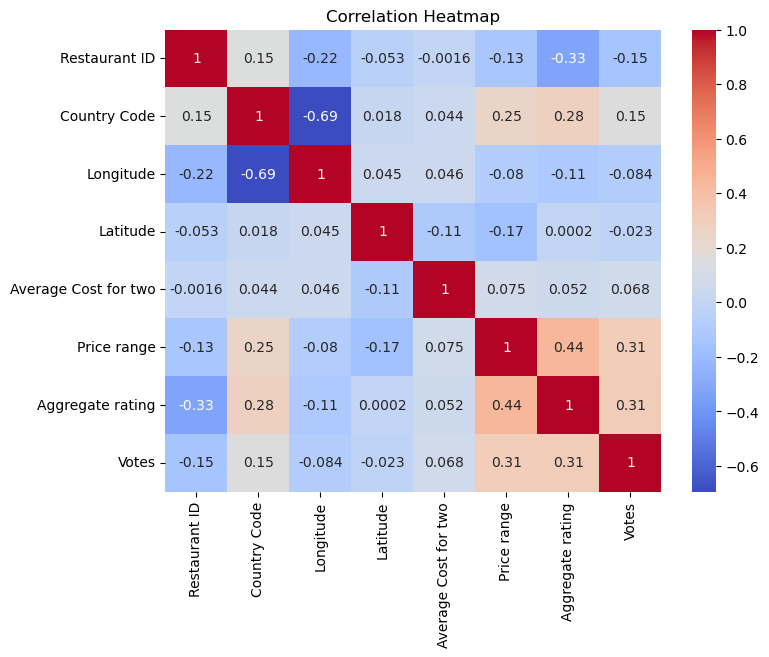

In [35]:
# selecting only numerical columns

numeric_df = df.select_dtypes(include=["int64","float64"])

# calculating correlation

corr = numeric_df.corr()

# plotting heatmap

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

The correlation heatmap shows relationships between numerical variables in the dataset.
-Price range has a moderate positive correlation with aggregate rating (0.44), which suggests that more expensive restaurants tend to have slightly higher ratings.
-Votes also show a positive correlation with ratings (0.31), indicating that restaurants with more customer reviews generally have better ratings.
-Average cost for two has a small positive relationship with price range, which is expected since more expensive restaurants usually fall into higher price categories.
-Overall, ratings are influenced more by popularity (votes) and price range than by location-related features such as latitude and longitude.

-Exploratory Data Analysis was performed on the restaurant dataset to understand patterns related to restaurant popularity, ratings, cuisines, and pricing.
-The dataset contained over 9500 restaurants across multiple countries, with India contributing the majority of the data. City-level analysis showed that New Delhi, Gurgaon, and Noida have the highest concentration of restaurants.
-Cuisine analysis revealed that North Indian, Chinese, and Fast Food are the most common cuisines in the dataset. This indicates strong regional food preferences.
-Rating distribution showed that most restaurants fall between ratings of 3 and 4, while a large number of restaurants have no ratings.
-Restaurants offering online delivery generally have higher average ratings compared to those that do not provide delivery services.
-The relationship between votes and ratings showed that restaurants with more customer reviews tend to maintain higher and more reliable ratings.
-Price range analysis indicated that most restaurants fall into the low-cost and moderate price categories.
-Correlation analysis further confirmed that ratings are moderately related to price range and number of votes.

These insights can help build a recommendation system that suggests restaurants based on cuisine preference, popularity, rating, price range, and service availability.